# Skin Disease Classification — Multiclass
### FYP Deep Learning Pipeline

This notebook trains three models — **MobileNetV2**, **VGG16**, and **ResNet50** — using Transfer Learning on an **11-class** classification task:

- `Vitiligo` (single class)
- `tinea-body`, `tinea-face`, `tinea-foot-dorsum`, `tinea-foot-plantar`
- `tinea-foot-webs`, `tinea-groin`, `tinea-hand-dorsum`, `tinea-palm`
- `tinea-scalp`, `tinea-versicolor`

---

**Directory Structure Expected:**
```
FYP/
├── Train/
│   ├── Vitiligo/
│   ├── tinea-body/
│   ├── tinea-face/
│   └── ... (all 11 classes)
├── Val/
│   └── ... (same 11 classes)
├── Test/
│   └── ... (same 11 classes)
└── main.ipynb
```

In [ ]:
# Mount Google Drive so we can read the dataset stored there
from google.colab import drive
drive.mount('/content/drive')  # Files become accessible at /content/drive/MyDrive/...


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1 — Import Libraries

In [1]:
import os                           # File system utilities: listing directories, joining paths
import numpy as np                  # Numerical arrays and math operations
import matplotlib.pyplot as plt     # Plotting: training curves and comparison bar charts
import tensorflow as tf             # Core deep learning framework
from tensorflow import keras                                            # High-level neural network API
from tensorflow.keras import layers                                     # Layer building blocks (Dense, Dropout, etc.)
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2  # ImageNet pre-trained backbones
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau  # Training control
from sklearn.utils.class_weight import compute_class_weight             # Handle imbalanced class counts
from sklearn.metrics import (
    classification_report, confusion_matrix,                           # Per-class and matrix evaluation
    accuracy_score, precision_score, recall_score, f1_score            # Aggregate metrics
)
from tensorflow.keras.models import load_model
import seaborn as sns               # Statistical visualisation (confusion matrix heatmap)
import warnings
warnings.filterwarnings('ignore')   # Suppress non-critical warnings to keep output readable

# Verify TensorFlow version and check GPU availability
print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2 — Configuration

All settings in one place. Edit paths here before running.

In [3]:
# ── Paths ──────────────────────────────────────────────
# Google Drive paths to each dataset split (one sub-folder per class inside each split)
TRAIN_DIR = '/content/drive/MyDrive/Classified_dataset/Train'   # Training images
VAL_DIR   = '/content/drive/MyDrive/Classified_dataset/Val'     # Validation images (used during training)
TEST_DIR  = '/content/drive/MyDrive/Classified_dataset/Test'    # Test images (evaluated only after training)

# ── Image Settings ─────────────────────────────────────
IMG_SIZE   = (224, 224)   # All three backbones expect 224x224 pixel inputs
BATCH_SIZE = 25           # Images processed per gradient-update step

# ── Training Settings ──────────────────────────────────
EPOCHS_HEAD     = 25    # Max epochs — Phase 1 (classification head only)
EPOCHS_FINETUNE = 25    # Max epochs — Phase 2 (last backbone layers + head)
LR_HEAD         = 1e-4  # Higher LR for Phase 1: head weights are randomly initialised
LR_FINETUNE     = 1e-5  # Lower LR for Phase 2: avoid overwriting learnt backbone features

# ── Seed ───────────────────────────────────────────────
# Fixing seeds makes shuffling, weight init, and dropout reproducible across runs
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('Configuration set.')


Configuration set.


## Step 3 — Load Dataset

Using `image_dataset_from_directory()` with `label_mode='int'` for multiclass classification.
TensorFlow assigns class indices alphabetically.

In [4]:
# Training dataset — shuffle=True randomises order each epoch to prevent order memorisation
# label_mode='int' yields integer labels (0..10) compatible with sparse_categorical_crossentropy
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode='int'
)

# Validation dataset — shuffle=False keeps order stable for consistent metrics
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode='int'
)

# Test dataset — never seen during training; used only for final evaluation
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode='int'
)

# TensorFlow names classes alphabetically from sub-folder names
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)   # Expected: 11

print(f'Number of classes : {NUM_CLASSES}')
print(f'Class names       : {CLASS_NAMES}')
print(f'Train batches     : {len(train_ds)}')
print(f'Val batches       : {len(val_ds)}')
print(f'Test batches      : {len(test_ds)}')


Found 1753 files belonging to 11 classes.
Found 432 files belonging to 11 classes.
Found 437 files belonging to 11 classes.
Number of classes : 11
Class names       : ['Vitiligo', 'tinea-body', 'tinea-face', 'tinea-foot-dorsum', 'tinea-foot-plantar', 'tinea-foot-webs', 'tinea-groin', 'tinea-hand-dorsum', 'tinea-palm', 'tinea-scalp', 'tinea-versicolor']
Train batches     : 71
Val batches       : 18
Test batches      : 18


## Step 4 — Preprocessing & Augmentation

- **Train**: Augmentation + ImageNet normalization
- **Val/Test**: Normalization only (no augmentation)

In [5]:
# ImageNet normalisation values — pre-trained models expect input in this distribution
IMAGENET_MEAN = [0.485, 0.456, 0.406]   # Per-channel mean  (R, G, B)
IMAGENET_STD  = [0.229, 0.224, 0.225]   # Per-channel std   (R, G, B)

def normalize(image, label):
    """Scale pixels to [0,1] then standardise with ImageNet mean/std."""
    image = tf.cast(image, tf.float32) / 255.0   # uint8 [0-255] -> float32 [0-1]
    mean  = tf.constant(IMAGENET_MEAN)
    std   = tf.constant(IMAGENET_STD)
    image = (image - mean) / std                  # Standardise each channel
    return image, label

# Augmentation is applied only during training to artificially increase dataset diversity
# and reduce the risk of overfitting on the small tinea sub-classes
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),     # Mirror image left-to-right randomly
    layers.RandomRotation(0.1),          # Rotate by up to 10% of 360 deg (~36 deg)
    layers.RandomZoom(0.1),              # Zoom in/out by up to 10%
    layers.RandomBrightness(0.1),        # Adjust brightness randomly by +/- 10%
], name='augmentation')

def augment(image, label):
    """Apply random augmentations to a training batch."""
    image = augmentation(image, training=True)   # training=True activates random ops
    return image, label

# AUTOTUNE allows TensorFlow to dynamically tune parallelism for best throughput
AUTOTUNE = tf.data.AUTOTUNE

# Training pipeline: augment -> normalise -> prefetch
# Prefetch overlaps data preparation with model execution, reducing idle GPU time
train_ds = train_ds.map(augment,   num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(normalize, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Val/Test: normalise only — no augmentation so we evaluate on realistic images
val_ds   = val_ds.map(normalize,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(normalize,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Preprocessing complete.')


Preprocessing complete.


## Step 5 — Class Weights

Vitiligo (1250) vastly outnumbers tinea subclasses (34–80 images).
Class weights ensure the model pays proportional attention to all classes.

In [6]:
# Count images per class from the filesystem (faster than scanning the full TF dataset)
all_labels = []
for idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)   # Path to the class sub-folder
    count    = len(os.listdir(cls_path))      # Number of image files inside
    all_labels.extend([idx] * count)          # Append class index 'count' times
    print(f'  Class {idx:>2} — {cls:<25}: {count} images')

# sklearn expects a NumPy array of all training labels
labels_array  = np.array(all_labels)
class_indices = np.arange(NUM_CLASSES)   # [0, 1, 2, ..., 10]

# 'balanced' weight formula: total_samples / (n_classes * count_i)
# -> minority classes receive a higher weight, making their loss more impactful
weights = compute_class_weight(
    class_weight='balanced',
    classes=class_indices,
    y=labels_array
)

# Convert to dict format {0: w0, 1: w1, ...} required by Keras model.fit()
class_weights = {i: weights[i] for i in range(NUM_CLASSES)}

print('\nClass weights:')
for idx, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:<25}: {class_weights[idx]:.4f}')


  Class  0 — Vitiligo                 : 1285 images
  Class  1 — tinea-body               : 74 images
  Class  2 — tinea-face               : 37 images
  Class  3 — tinea-foot-dorsum        : 36 images
  Class  4 — tinea-foot-plantar       : 36 images
  Class  5 — tinea-foot-webs          : 48 images
  Class  6 — tinea-groin              : 72 images
  Class  7 — tinea-hand-dorsum        : 44 images
  Class  8 — tinea-palm               : 34 images
  Class  9 — tinea-scalp              : 42 images
  Class 10 — tinea-versicolor         : 80 images

Class weights:
  Vitiligo                 : 0.1265
  tinea-body               : 2.1966
  tinea-face               : 4.3931
  tinea-foot-dorsum        : 4.5152
  tinea-foot-plantar       : 4.5152
  tinea-foot-webs          : 3.3864
  tinea-groin              : 2.2576
  tinea-hand-dorsum        : 3.6942
  tinea-palm               : 4.7807
  tinea-scalp              : 3.8701
  tinea-versicolor         : 2.0318


## Step 6 — Callbacks

- **EarlyStopping** — stops if val_loss stalls (patience=5)
- **ModelCheckpoint** — saves best model per phase
- **ReduceLROnPlateau** — halves LR when improvement stalls

In [7]:
def get_callbacks(model_name):
    """Return training callbacks: early stopping, checkpointing, and LR reduction."""
    return [
        # Stop training when val_loss shows no improvement for 5 straight epochs;
        # restore_best_weights recovers the checkpoint with the lowest val_loss
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        # Persist model weights whenever a new best val_loss is achieved
        ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        # Halve the learning rate (factor=0.5) after 3 stagnant epochs;
        # min_lr=1e-7 sets a floor so the LR never becomes negligibly small
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]


## Step 7 — Model Builder

Reusable function for all three backbones.

Key multiclass changes vs binary:
- Output: `Dense(NUM_CLASSES, softmax)` — one probability per class
- Loss: `sparse_categorical_crossentropy` — works with integer labels directly

PS: it is pretrained in the final model from 25 epochs/

## Step 8 — Train MobileNetV2

In [9]:
# Continue MobileNetV2
mobilenet_model = load_model('/content/drive/MyDrive/Classified_dataset/best_mobilenet_phase2.keras')
mobilenet_history_3 = mobilenet_model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weights,
    callbacks=get_callbacks('mobilenet_phase3')
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.8735 - loss: 0.6176
Epoch 1: val_loss improved from None to 0.47687, saving model to best_mobilenet_phase3.keras

Epoch 1: finished saving model to best_mobilenet_phase3.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 83s 741ms/step - accuracy: 0.8694 - loss: 0.6503 - val_accuracy: 0.8495 - val_loss: 0.4769 - learning_rate: 1.0000e-05
Epoch 2/15
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.8579 - loss: 0.6225
Epoch 2: val_loss did not improve from 0.47687
71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 373ms/step - accuracy: 0.8580 - loss: 0.6856 - val_accuracy: 0.8403 - val_loss: 0.4918 - learning_rate: 1.0000e-05
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.8841 - loss: 0.5466
Epoch 3: val_loss did not improve from 0.47687
71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 373ms/step - accuracy: 0.8728 - loss: 0.5931 - val_accuracy: 0.8426 - val_loss: 0.4918 - learning_rate: 1.0000e-05
Epoch 4/15
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - 

## Step 9 — Train VGG16

In [10]:
# Continue VGG16
vgg_model = load_model('/content/drive/MyDrive/Classified_dataset/best_vgg16_phase2.keras')
vgg_history_3 = vgg_model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weights,
    callbacks=get_callbacks('vgg16_phase3')
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9511 - loss: 0.2697
Epoch 1: val_loss improved from None to 0.25310, saving model to best_vgg16_phase3.keras

Epoch 1: finished saving model to best_vgg16_phase3.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 57s 561ms/step - accuracy: 0.9487 - loss: 0.3062 - val_accuracy: 0.9144 - val_loss: 0.2531 - learning_rate: 5.0000e-06
Epoch 2/15
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9408 - loss: 0.2973
Epoch 2: val_loss did not improve from 0.25310
71/71 ━━━━━━━━━━━━━━━━━━━━ 30s 409ms/step - accuracy: 0.9435 - loss: 0.2954 - val_accuracy: 0.9120 - val_loss: 0.2557 - learning_rate: 5.0000e-06
Epoch 3/15
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9500 - loss: 0.2539
Epoch 3: val_loss improved from 0.25310 to 0.19984, saving model to best_vgg16_phase3.keras

Epoch 3: finished saving model to best_vgg16_phase3.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 422ms/step - accuracy: 0.9481 - loss: 0.2889 - val_accuracy: 0.9306 - val

## Step 10 — Train ResNet50


In [11]:
# Continue ResNet50
resnet_model = load_model('/content/drive/MyDrive/Classified_dataset/best_resnet50_phase2.keras')
resnet_history_3 = resnet_model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weights,
    callbacks=get_callbacks('resnet50_phase3')
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.6743 - loss: 1.4149
Epoch 1: val_loss improved from None to 1.00166, saving model to best_resnet50_phase3.keras

Epoch 1: finished saving model to best_resnet50_phase3.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 59s 553ms/step - accuracy: 0.6703 - loss: 1.4681 - val_accuracy: 0.7153 - val_loss: 1.0017 - learning_rate: 1.0000e-05
Epoch 2/15
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.6634 - loss: 1.4408
Epoch 2: val_loss improved from 1.00166 to 0.98580, saving model to best_resnet50_phase3.keras

Epoch 2: finished saving model to best_resnet50_phase3.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 29s 400ms/step - accuracy: 0.6891 - loss: 1.4072 - val_accuracy: 0.7060 - val_loss: 0.9858 - learning_rate: 1.0000e-05
Epoch 3/15
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.6773 - loss: 1.3708
Epoch 3: val_loss improved from 0.98580 to 0.98094, saving model to best_resnet50_phase3.keras

Epoch 3: finished saving model to best_resn

## Step 11 — Training Curves

Combined Phase 1 + Phase 2 accuracy/loss plots. Red line marks start of fine-tuning.

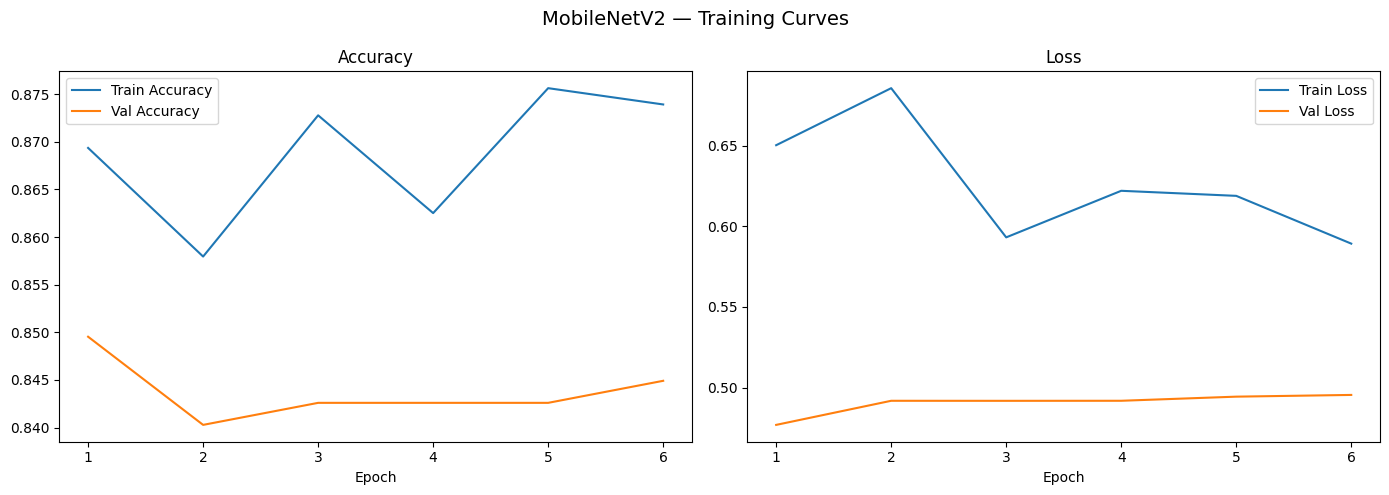

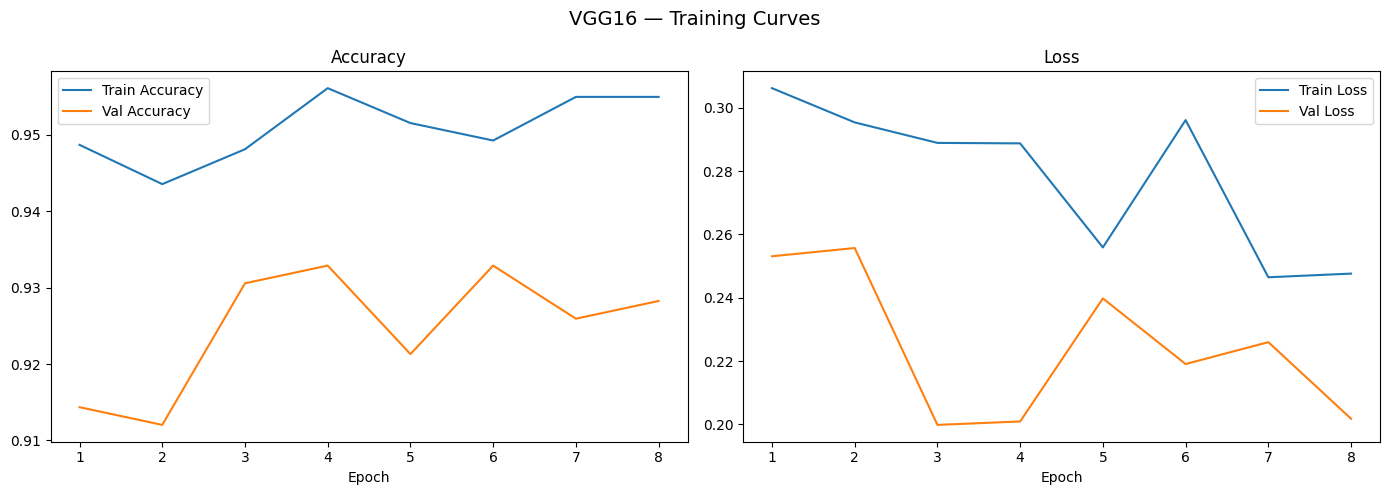

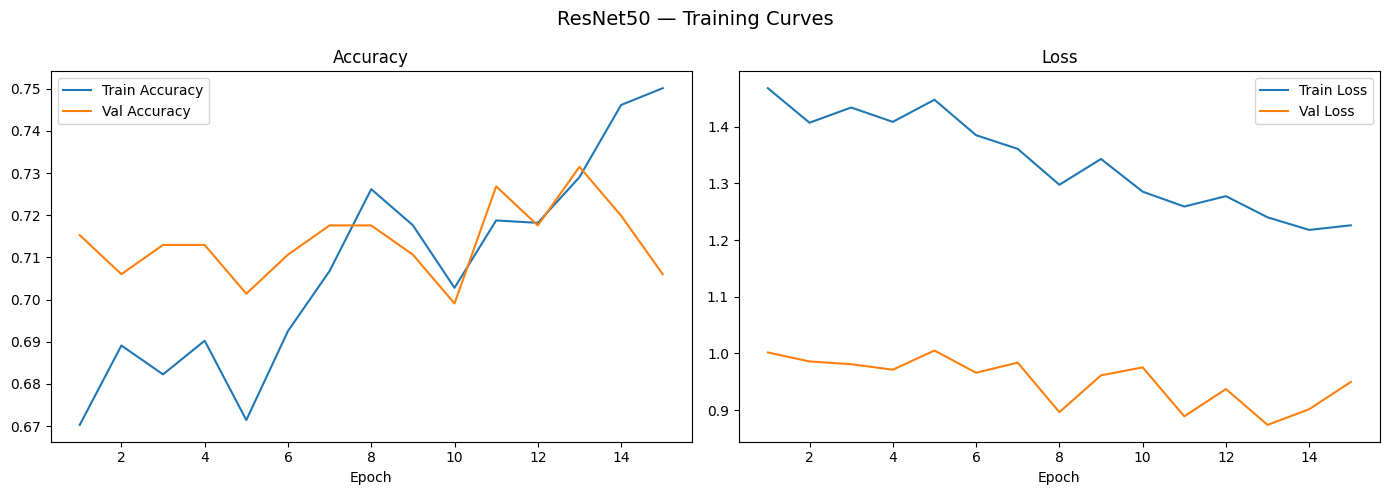

In [16]:
def plot_history(histories_list, model_name):
    """
    Plot accuracy and loss curves across multiple training phases.

    Concatenates history objects into a single timeline.
    Vertical dashed red lines mark the transitions between training phases.
    """
    if not histories_list:
        print(f"No histories provided for {model_name}.")
        return

    # Concatenate metrics from all history objects
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for h in histories_list:
        acc.extend(h.history['accuracy'])
        val_acc.extend(h.history['val_accuracy'])
        loss.extend(h.history['loss'])
        val_loss.extend(h.history['val_loss'])

    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training Curves', fontsize=14)

    # Plot Accuracy
    ax1.plot(epochs, acc,     label='Train Accuracy')
    ax1.plot(epochs, val_acc, label='Val Accuracy')
    current_epoch_boundary = 0
    for i, h in enumerate(histories_list):
        current_epoch_boundary += len(h.history['accuracy'])
        if i < len(histories_list) - 1:
            ax1.axvline(current_epoch_boundary, color='red', linestyle='--', label=f'Phase {i+1} end')
    ax1.set_title('Accuracy') ; ax1.set_xlabel('Epoch') ; ax1.legend()

    # Plot Loss
    ax2.plot(epochs, loss,     label='Train Loss')
    ax2.plot(epochs, val_loss, label='Val Loss')
    current_epoch_boundary = 0
    for i, h in enumerate(histories_list):
        current_epoch_boundary += len(h.history['accuracy'])
        if i < len(histories_list) - 1:
            ax2.axvline(current_epoch_boundary, color='red', linestyle='--', label=f'Phase {i+1} end')
    ax2.set_title('Loss') ; ax2.set_xlabel('Epoch') ; ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_curves.png', dpi=150)
    plt.show()

# Collect all available histories for MobileNetV2
mobilenet_histories = []
if 'mobilenet_history_1' in globals() and mobilenet_history_1 is not None:
    mobilenet_histories.append(mobilenet_history_1)
if 'mobilenet_history_2' in globals() and mobilenet_history_2 is not None:
    mobilenet_histories.append(mobilenet_history_2)
if 'mobilenet_history_3' in globals() and mobilenet_history_3 is not None:
    mobilenet_histories.append(mobilenet_history_3)
plot_history(mobilenet_histories, 'MobileNetV2')

# Collect all available histories for VGG16
vgg_histories = []
if 'vgg_history_1' in globals() and vgg_history_1 is not None:
    vgg_histories.append(vgg_history_1)
if 'vgg_history_2' in globals() and vgg_history_2 is not None:
    vgg_histories.append(vgg_history_2)
if 'vgg_history_3' in globals() and vgg_history_3 is not None:
    vgg_histories.append(vgg_history_3)
plot_history(vgg_histories, 'VGG16')

# Collect all available histories for ResNet50
resnet_histories = []
if 'resnet_history_1' in globals() and resnet_history_1 is not None:
    resnet_histories.append(resnet_history_1)
if 'resnet_history_2' in globals() and resnet_history_2 is not None:
    resnet_histories.append(resnet_history_2)
if 'resnet_history_3' in globals() and resnet_history_3 is not None:
    resnet_histories.append(resnet_history_3)
plot_history(resnet_histories, 'ResNet50')


## Step 12 — Evaluation on Test Set

Per-class precision, recall, F1-score and confusion matrix for each model.


--------------------------------------------------
  Evaluating MobileNetV2
--------------------------------------------------
18/18 ━━━━━━━━━━━━━━━━━━━━ 124s 7s/step

Classification Report:
                    precision    recall  f1-score   support

          Vitiligo       1.00      0.97      0.98       267
        tinea-body       0.76      0.76      0.76        29
        tinea-face       0.74      0.88      0.80        16
 tinea-foot-dorsum       0.54      0.64      0.58        11
tinea-foot-plantar       0.62      0.56      0.59         9
   tinea-foot-webs       0.93      0.76      0.84        17
       tinea-groin       1.00      0.79      0.88        29
 tinea-hand-dorsum       0.62      0.73      0.67        11
        tinea-palm       0.50      0.67      0.57         6
       tinea-scalp       0.88      0.93      0.90        15
  tinea-versicolor       0.69      0.89      0.77        27

          accuracy                           0.90       437
         macro avg       0

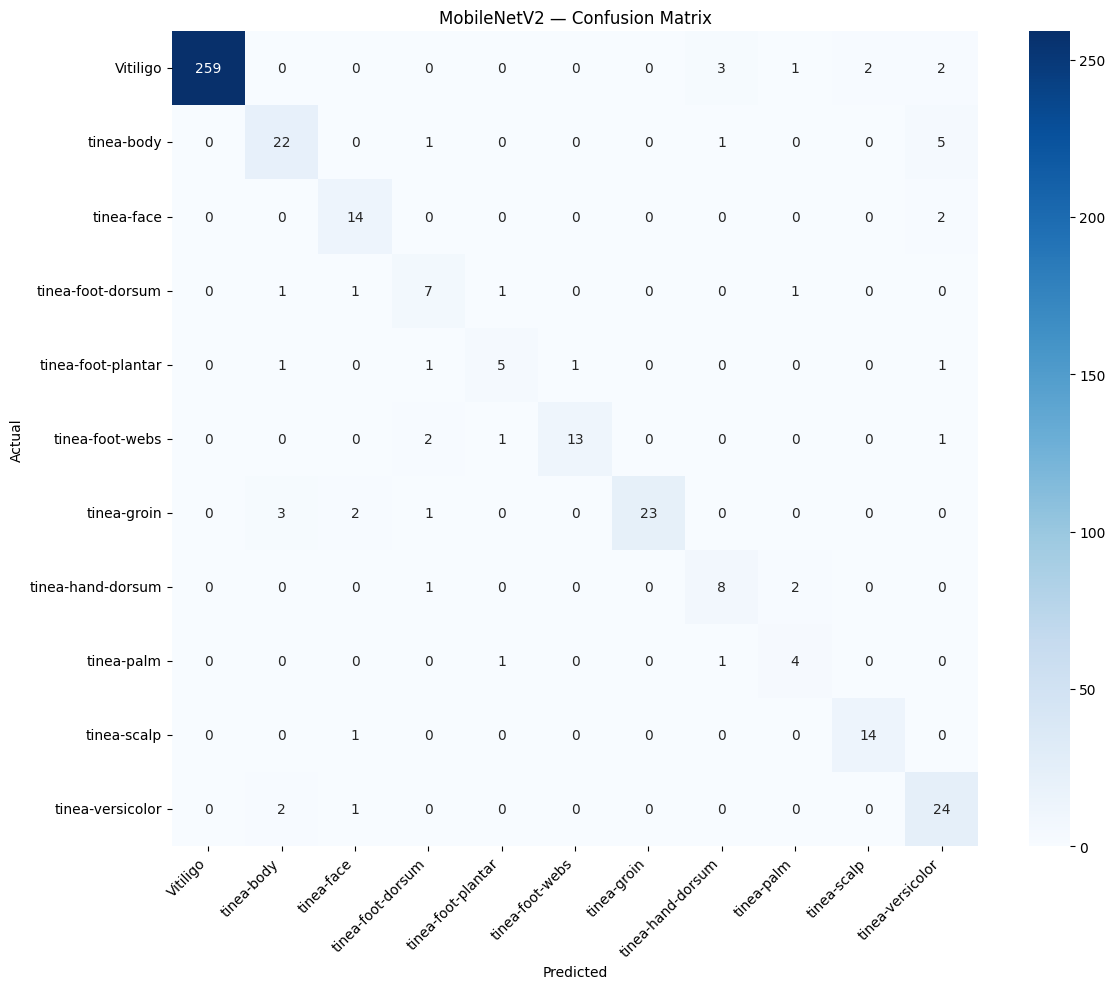


--------------------------------------------------
  Evaluating VGG16
--------------------------------------------------
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 448ms/step

Classification Report:
                    precision    recall  f1-score   support

          Vitiligo       1.00      1.00      1.00       267
        tinea-body       0.73      0.66      0.69        29
        tinea-face       0.87      0.81      0.84        16
 tinea-foot-dorsum       0.43      0.27      0.33        11
tinea-foot-plantar       0.50      0.89      0.64         9
   tinea-foot-webs       0.93      0.82      0.88        17
       tinea-groin       0.96      0.93      0.95        29
 tinea-hand-dorsum       0.75      0.82      0.78        11
        tinea-palm       0.75      1.00      0.86         6
       tinea-scalp       0.88      0.93      0.90        15
  tinea-versicolor       0.79      0.81      0.80        27

          accuracy                           0.92       437
         macro avg       0.78  

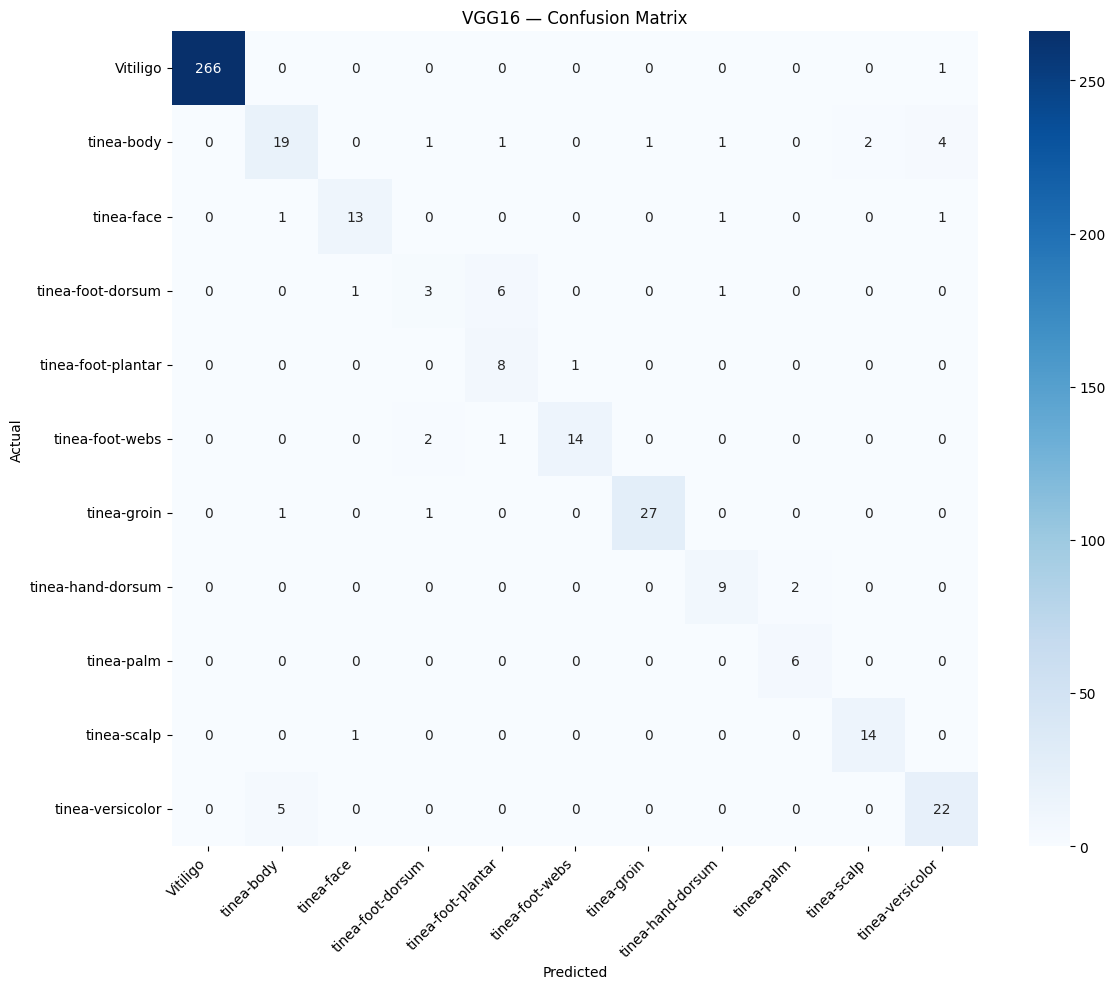


--------------------------------------------------
  Evaluating ResNet50
--------------------------------------------------
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 393ms/step

Classification Report:
                    precision    recall  f1-score   support

          Vitiligo       0.97      0.90      0.93       267
        tinea-body       0.46      0.21      0.29        29
        tinea-face       0.00      0.00      0.00        16
 tinea-foot-dorsum       0.25      0.18      0.21        11
tinea-foot-plantar       0.44      0.44      0.44         9
   tinea-foot-webs       0.50      0.53      0.51        17
       tinea-groin       0.65      0.59      0.62        29
 tinea-hand-dorsum       0.29      0.36      0.32        11
        tinea-palm       0.33      0.83      0.48         6
       tinea-scalp       0.37      1.00      0.54        15
  tinea-versicolor       0.38      0.67      0.49        27

          accuracy                           0.73       437
         macro avg       0.

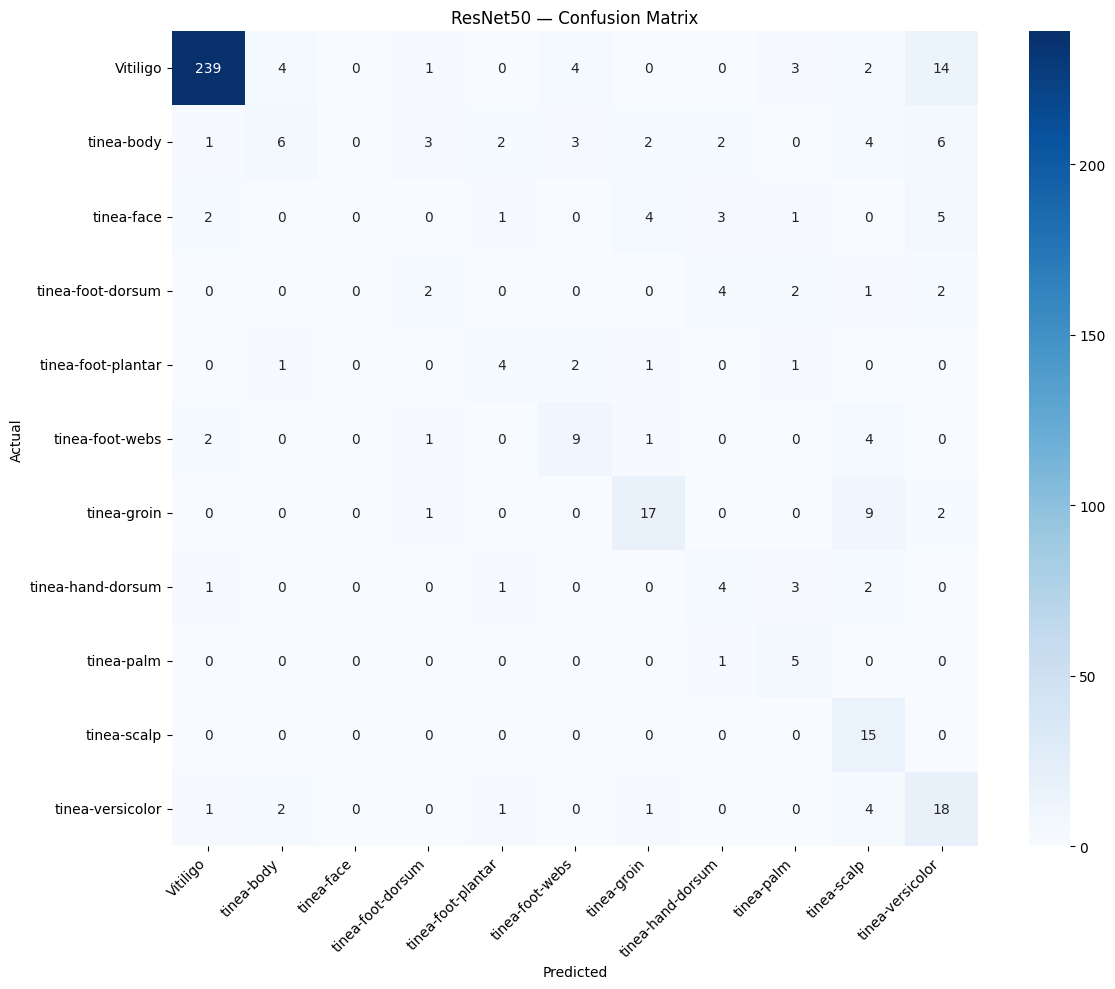

In [17]:
def evaluate_model(model, test_ds, model_name):
    print(f'\n{"-"*50}')
    print(f'  Evaluating {model_name}')
    print(f'{"-"*50}')

    y_pred_probs = model.predict(test_ds)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = np.concatenate([y for x, y in test_ds], axis=0).astype(int)

    # Classification Report
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    # Weighted + Macro metrics
    print(f'Accuracy                  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision (weighted)      : {precision_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')
    print(f'Precision (macro)         : {precision_score(y_true, y_pred, average="macro",    zero_division=0):.4f}')
    print(f'Recall    (weighted)      : {recall_score(y_true, y_pred,    average="weighted", zero_division=0):.4f}')
    print(f'Recall    (macro)         : {recall_score(y_true, y_pred,    average="macro",    zero_division=0):.4f}')
    print(f'F1-Score  (weighted)      : {f1_score(y_true, y_pred,        average="weighted", zero_division=0):.4f}')
    print(f'F1-Score  (macro)         : {f1_score(y_true, y_pred,        average="macro",    zero_division=0):.4f}')

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=150)
    plt.show()

    return {
        'model'    : model_name,
        'y_true'   : y_true,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision_w': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_m': precision_score(y_true, y_pred, average='macro',    zero_division=0),
        'recall_w'   : recall_score(y_true, y_pred,    average='weighted', zero_division=0),
        'recall_m'   : recall_score(y_true, y_pred,    average='macro',    zero_division=0),
        'f1_w'       : f1_score(y_true, y_pred,        average='weighted', zero_division=0),
        'f1_m'       : f1_score(y_true, y_pred,        average='macro',    zero_division=0),
    }

mobilenet_results = evaluate_model(mobilenet_model, test_ds, 'MobileNetV2')
vgg_results       = evaluate_model(vgg_model,       test_ds, 'VGG16')
resnet_results    = evaluate_model(resnet_model,    test_ds, 'ResNet50')

## Step 13 — Model Comparison

Weighted average metrics across all 11 classes for final comparison.


   MobileNetV2 vs VGG16 vs ResNet50 — Final Comparison
Metric             MobileNetV2      VGG16   ResNet50
----------------------------------------------------------------------
Accuracy                0.8993     0.9176       0.73
Precision (W)            0.912     0.9204     0.7505
Precision (M)           0.7512     0.7804     0.4227
Recall (W)              0.8993     0.9176       0.73
Recall (M)               0.779     0.8133     0.5189
F1 (W)                  0.9029     0.9168     0.7268
F1 (M)                  0.7594     0.7879     0.4385


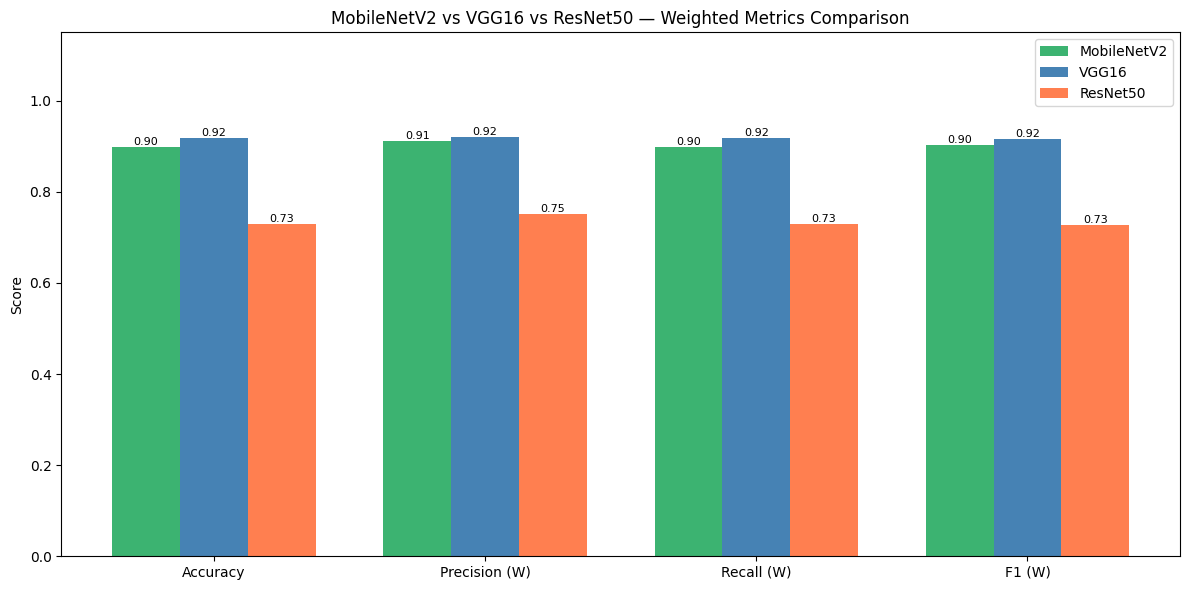

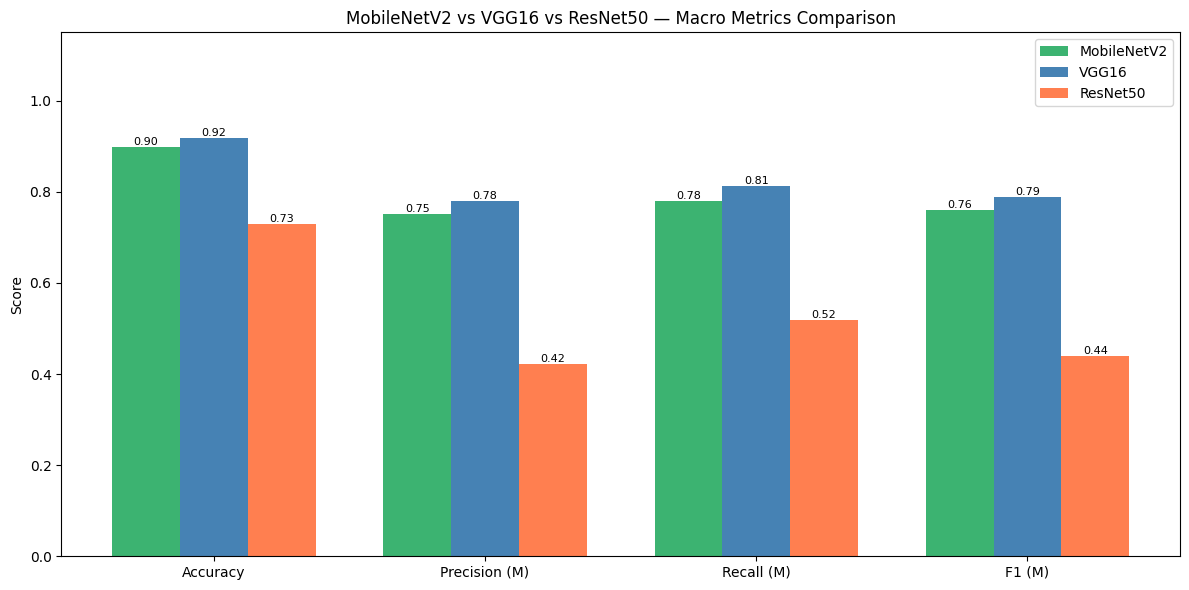

In [22]:
def get_metrics(results):
    return {
        'Model'          : results['model'],
        'Accuracy'       : round(results['accuracy'],    4),
        'Precision (W)'  : round(results['precision_w'], 4),
        'Precision (M)'  : round(results['precision_m'], 4),
        'Recall (W)'     : round(results['recall_w'],    4),
        'Recall (M)'     : round(results['recall_m'],    4),
        'F1 (W)'         : round(results['f1_w'],        4),
        'F1 (M)'         : round(results['f1_m'],        4),
    }

mobilenet_metrics = get_metrics(mobilenet_results)
vgg_metrics       = get_metrics(vgg_results)
resnet_metrics    = get_metrics(resnet_results)

print('\n' + '=' * 70)
print('   MobileNetV2 vs VGG16 vs ResNet50 — Final Comparison')
print('=' * 70)
# Adjusted column width for 'Metric' and increased total separator length
print(f'{"Metric":<15} {"MobileNetV2":>14} {"VGG16":>10} {"ResNet50":>10}')
print('-' * 70)
# Now includes both weighted and macro metrics
for key in ['Accuracy', 'Precision (W)', 'Precision (M)', 'Recall (W)', 'Recall (M)', 'F1 (W)', 'F1 (M)']:
    print(f'{key:<15} {mobilenet_metrics[key]:>14} {vgg_metrics[key]:>10} {resnet_metrics[key]:>10}')
print('=' * 70)

# ── Bar chart: visualise the comparison for Weighted Metrics ──────────
metrics_names_w  = ['Accuracy', 'Precision (W)', 'Recall (W)', 'F1 (W)']
mobilenet_vals_w = [mobilenet_metrics[m] for m in metrics_names_w]
vgg_vals_w       = [vgg_metrics[m]       for m in metrics_names_w]
resnet_vals_w    = [resnet_metrics[m]    for m in metrics_names_w]

x_w     = np.arange(len(metrics_names_w))
width_w = 0.25

fig_w, ax_w = plt.subplots(figsize=(12, 6))
ax_w.bar(x_w - width_w, mobilenet_vals_w, width_w, label='MobileNetV2', color='mediumseagreen')
ax_w.bar(x_w,         vgg_vals_w,       width_w, label='VGG16',       color='steelblue')
ax_w.bar(x_w + width_w, resnet_vals_w,    width_w, label='ResNet50',    color='coral')
ax_w.set_xticks(x_w)
ax_w.set_xticklabels(metrics_names_w)
ax_w.set_ylim(0, 1.15)
ax_w.set_title('MobileNetV2 vs VGG16 vs ResNet50 — Weighted Metrics Comparison')
ax_w.legend() ; ax_w.set_ylabel('Score')
for bar in ax_w.patches:
    ax_w.annotate(f'{bar.get_height():.2f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('MobileNetV2_vs_VGG16_vs_ResNet50_weighted_comparison.png', dpi=150)
plt.show()

# ── Bar chart: visualise the comparison for Macro Metrics ──────────
metrics_names_m  = ['Accuracy', 'Precision (M)', 'Recall (M)', 'F1 (M)']
mobilenet_vals_m = [mobilenet_metrics[m] for m in metrics_names_m]
vgg_vals_m       = [vgg_metrics[m]       for m in metrics_names_m]
resnet_vals_m    = [resnet_metrics[m]    for m in metrics_names_m]

x_m     = np.arange(len(metrics_names_m))
width_m = 0.25

fig_m, ax_m = plt.subplots(figsize=(12, 6))
ax_m.bar(x_m - width_m, mobilenet_vals_m, width_m, label='MobileNetV2', color='mediumseagreen')
ax_m.bar(x_m,         vgg_vals_m,       width_m, label='VGG16',       color='steelblue')
ax_m.bar(x_m + width_m, resnet_vals_m,    width_m, label='ResNet50',    color='coral')
ax_m.set_xticks(x_m)
ax_m.set_xticklabels(metrics_names_m)
ax_m.set_ylim(0, 1.15)
ax_m.set_title('MobileNetV2 vs VGG16 vs ResNet50 — Macro Metrics Comparison')
ax_m.legend() ; ax_m.set_ylabel('Score')
for bar in ax_m.patches:
    ax_m.annotate(f'{bar.get_height():.2f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('MobileNetV2_vs_VGG16_vs_ResNet50_macro_comparison.png', dpi=150)
plt.show()

## Step 14 — Save Models

In [20]:
# Save final models in Keras native format.
# These reflect the post-fine-tuning weights and are ready for inference or deployment.
# (ModelCheckpoint already saved the best validation-loss checkpoints during training.)
mobilenet_model.save('mobilenet_final.keras')
vgg_model.save('vgg16_final.keras')
resnet_model.save('resnet50_final.keras')

print('Models saved:')
print('  mobilenet_final.keras')
print('  vgg16_final.keras')
print('  resnet50_final.keras')


Models saved:
  mobilenet_final.keras
  vgg16_final.keras
  resnet50_final.keras
